# 🎓 Intern Performance Predictor
### Machine Learning with Random Forest & XGBoost

---

This notebook walks through the **complete ML pipeline** — from raw data to predictions — in 7 clear steps.

| Step | What happens |
|------|--------------|
| 1 | Install & import libraries |
| 2 | Generate synthetic intern dataset |
| 3 | Explore & visualize the data (EDA) |
| 4 | Engineer features |
| 5 | Train Random Forest & XGBoost models |
| 6 | Evaluate & compare models |
| 7 | Predict on new interns |

> **Run cells in order** — each step builds on the previous one. Use **Shift + Enter** to run a cell.

---
## Step 1 — Install & Import Libraries
Run this cell once. It installs any missing packages and imports everything needed for the notebook.

In [1]:
# ── Install required packages (safe to run multiple times) ────────────────────
import sys
!{sys.executable} -m pip install pandas numpy scikit-learn xgboost matplotlib seaborn joblib --quiet
print('✅  All packages ready')

✅  All packages ready


In [2]:
# ── Imports ───────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib, json
from pathlib import Path

from sklearn.ensemble         import RandomForestRegressor
from sklearn.linear_model     import Ridge
from sklearn.model_selection  import train_test_split, cross_val_score, KFold
from sklearn.preprocessing    import StandardScaler
from sklearn.metrics          import mean_squared_error, r2_score, mean_absolute_error
from xgboost                  import XGBRegressor

# ── Notebook display settings ─────────────────────────────────────────────────
%matplotlib inline
plt.rcParams.update({
    'figure.dpi':       120,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.size':        11,
})
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)

# ── Color palette ─────────────────────────────────────────────────────────────
CLR = {'Excel':'#639922', 'Watch':'#BA7517', 'Struggle':'#E24B4A',
       'blue':'#378ADD', 'teal':'#1D9E75', 'gray':'#888780'}

# ── Folder for saved models ───────────────────────────────────────────────────
MODELS_DIR = Path('models')
MODELS_DIR.mkdir(exist_ok=True)

print('✅  Imports complete')

✅  Imports complete


---
## Step 2 — Generate Synthetic Dataset

We simulate **200 intern records** with realistic distributions.

| Column | Description |
|--------|-------------|
| `task_completion_rate` | % of assigned tasks completed |
| `avg_feedback_score` | Manager/peer rating (1–5) |
| `attendance_pct` | % of days present |
| `avg_task_time_hrs` | Average hours per task |
| `early_feedback` | Feedback score in first month |
| `recent_feedback` | Feedback score in last month |
| `performance_score` | **Target variable** (0–100) |

> 💡 **Using real data?** Skip this cell and load your own CSV:
> ```python
> df = pd.read_csv('your_file.csv')
> ```

In [3]:
np.random.seed(42)
N = 200
DEPARTMENTS = ['Engineering', 'Data Science', 'Design', 'Marketing', 'Finance']

# ── Simulate raw inputs ───────────────────────────────────────────────────────
task_completion_rate = np.clip(np.random.normal(80, 12, N), 40, 100)
avg_feedback_score   = np.clip(np.random.normal(3.8, 0.7, N), 1.0, 5.0)
attendance_pct       = np.clip(np.random.normal(88, 8,  N), 60, 100)
avg_task_time_hrs    = np.clip(np.random.normal(4.5, 1.2, N), 1.5, 10.0)
early_feedback       = np.clip(np.random.normal(3.5, 0.8, N), 1.0, 5.0)
recent_feedback      = np.clip(early_feedback + np.random.normal(0.2, 0.3, N), 1.0, 5.0)

# ── Derived features (engineered) ────────────────────────────────────────────
completion_speed = task_completion_rate / (avg_task_time_hrs + 1)
feedback_trend   = recent_feedback - early_feedback
engagement_score = 0.4 * attendance_pct + 0.6 * task_completion_rate

# ── Target: weighted formula + noise ─────────────────────────────────────────
performance_score = (
    0.35 * task_completion_rate +
    0.28 * (avg_feedback_score / 5.0) * 100 +
    0.18 * attendance_pct +
    0.12 * np.clip(completion_speed * 5, 0, 100) +
    0.07 * np.clip((feedback_trend + 2) * 25, 0, 100) +
    np.random.normal(0, 3, N)
)
performance_score = np.clip(performance_score, 0, 100).round(1)

# ── Assemble DataFrame ────────────────────────────────────────────────────────
df = pd.DataFrame({
    'intern_id':            [f'INT{str(i).zfill(3)}' for i in range(1, N+1)],
    'department':           np.random.choice(DEPARTMENTS, N),
    'task_completion_rate': task_completion_rate.round(1),
    'avg_feedback_score':   avg_feedback_score.round(2),
    'attendance_pct':       attendance_pct.round(1),
    'avg_task_time_hrs':    avg_task_time_hrs.round(2),
    'early_feedback':       early_feedback.round(2),
    'recent_feedback':      recent_feedback.round(2),
    'completion_speed':     completion_speed.round(3),
    'feedback_trend':       feedback_trend.round(3),
    'engagement_score':     engagement_score.round(2),
    'performance_score':    performance_score,
})

# ── Risk tier label ───────────────────────────────────────────────────────────
df['risk_tier'] = pd.cut(
    df['performance_score'],
    bins=[0, 65, 80, 100],
    labels=['Struggle', 'Watch', 'Excel']
)

# ── Save to CSV ───────────────────────────────────────────────────────────────
df.to_csv('interns.csv', index=False)

print(f'✅  Dataset created: {N} rows × {df.shape[1]} columns')
print(f'   Saved → interns.csv')
print(f'\nRisk tier counts:')
print(df['risk_tier'].value_counts().to_string())
df.head()

✅  Dataset created: 200 rows × 13 columns
   Saved → interns.csv

Risk tier counts:
risk_tier
Watch       119
Excel        71
Struggle     10


,intern_id,department,task_completion_rate,avg_feedback_score,attendance_pct,avg_task_time_hrs,early_feedback,recent_feedback,completion_speed,feedback_trend,engagement_score,performance_score,risk_tier
0,INT001,Design,86.00,4.05,75.20,5.41,4.25,4.87,13.41,0.62,81.67,79.30,Watch
1,INT002,Marketing,78.30,4.19,83.20,3.39,3.09,3.56,17.83,0.48,80.29,79.60,Watch
2,INT003,Design,87.80,4.56,88.00,5.54,3.58,3.79,13.41,0.22,87.88,84.40,Excel
3,INT004,Design,98.30,4.54,88.40,6.13,3.13,3.14,13.79,0.01,94.32,89.10,Excel
4,INT005,Data Science,77.20,2.84,84.40,5.00,3.15,3.56,12.87,0.41,80.07,70.20,Watch


---
## Step 3 — Exploratory Data Analysis (EDA)

Before training, we need to understand the data: distributions, correlations, and class balance.

In [4]:
# ── 3a. Summary statistics ────────────────────────────────────────────────────
print('=== Summary Statistics ===')
display(df[['task_completion_rate','avg_feedback_score',
            'attendance_pct','performance_score']].describe().round(2))

print('\n=== Missing values ===')
print(df.isnull().sum())

=== Summary Statistics ===


,task_completion_rate,avg_feedback_score,attendance_pct,performance_score
count,200.00,200.00,200.00,200.00
mean,79.32,3.84,87.10,77.66
std,10.74,0.65,7.51,7.04
min,48.60,1.53,68.20,57.50
25%,71.55,3.38,81.68,73.90
50%,79.95,3.86,87.40,78.10
75%,86.05,4.28,92.60,81.88
max,100.00,5.00,100.00,93.00



=== Missing values ===
intern_id               0
department              0
task_completion_rate    0
avg_feedback_score      0
attendance_pct          0
avg_task_time_hrs       0
early_feedback          0
recent_feedback         0
completion_speed        0
feedback_trend          0
engagement_score        0
performance_score       0
risk_tier               0
dtype: int64


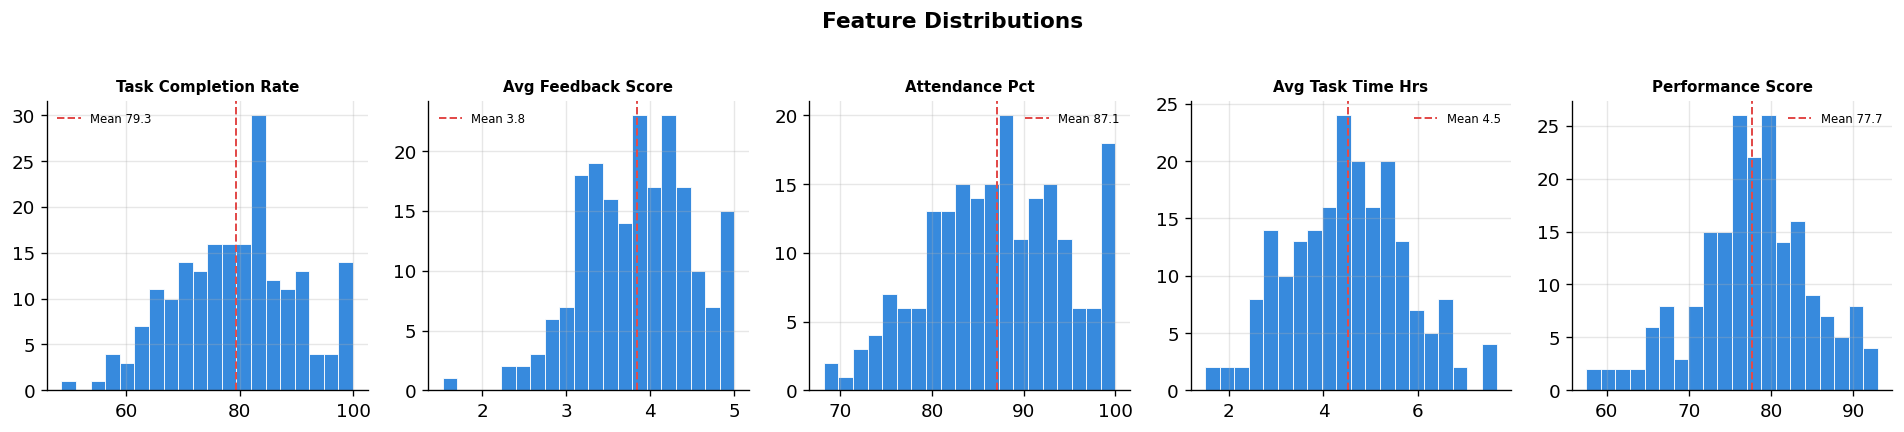

In [5]:
# ── 3b. Feature distributions ─────────────────────────────────────────────────
num_cols = ['task_completion_rate','avg_feedback_score',
            'attendance_pct','avg_task_time_hrs','performance_score']

fig, axes = plt.subplots(1, 5, figsize=(16, 3.5))
for ax, col in zip(axes, num_cols):
    ax.hist(df[col], bins=20, color=CLR['blue'], edgecolor='white', linewidth=0.5)
    ax.set_title(col.replace('_',' ').title(), fontsize=9, fontweight='bold')
    ax.set_xlabel('')
    mean_val = df[col].mean()
    ax.axvline(mean_val, color='#E24B4A', linestyle='--', linewidth=1.2, label=f'Mean {mean_val:.1f}')
    ax.legend(fontsize=7, frameon=False)

fig.suptitle('Feature Distributions', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

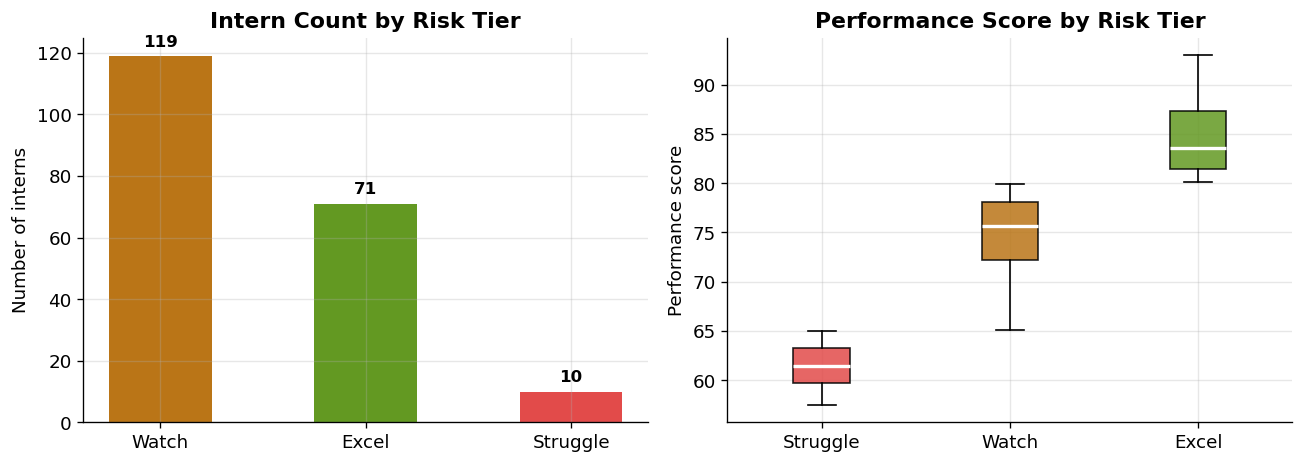

In [6]:
# ── 3c. Risk tier distribution ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
counts = df['risk_tier'].value_counts()
colors = [CLR[t] for t in counts.index]
bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='none', width=0.5)
axes[0].bar_label(bars, padding=4, fontsize=10, fontweight='bold')
axes[0].set_title('Intern Count by Risk Tier', fontweight='bold')
axes[0].set_ylabel('Number of interns')

# Performance score by tier (box plot)
tier_order = ['Struggle', 'Watch', 'Excel']
data_by_tier = [df[df['risk_tier']==t]['performance_score'].values for t in tier_order]
bp = axes[1].boxplot(data_by_tier, labels=tier_order, patch_artist=True, notch=False,
                     medianprops={'color':'white','linewidth':2})
for patch, tier in zip(bp['boxes'], tier_order):
    patch.set_facecolor(CLR[tier])
    patch.set_alpha(0.85)
axes[1].set_title('Performance Score by Risk Tier', fontweight='bold')
axes[1].set_ylabel('Performance score')

plt.tight_layout()
plt.show()

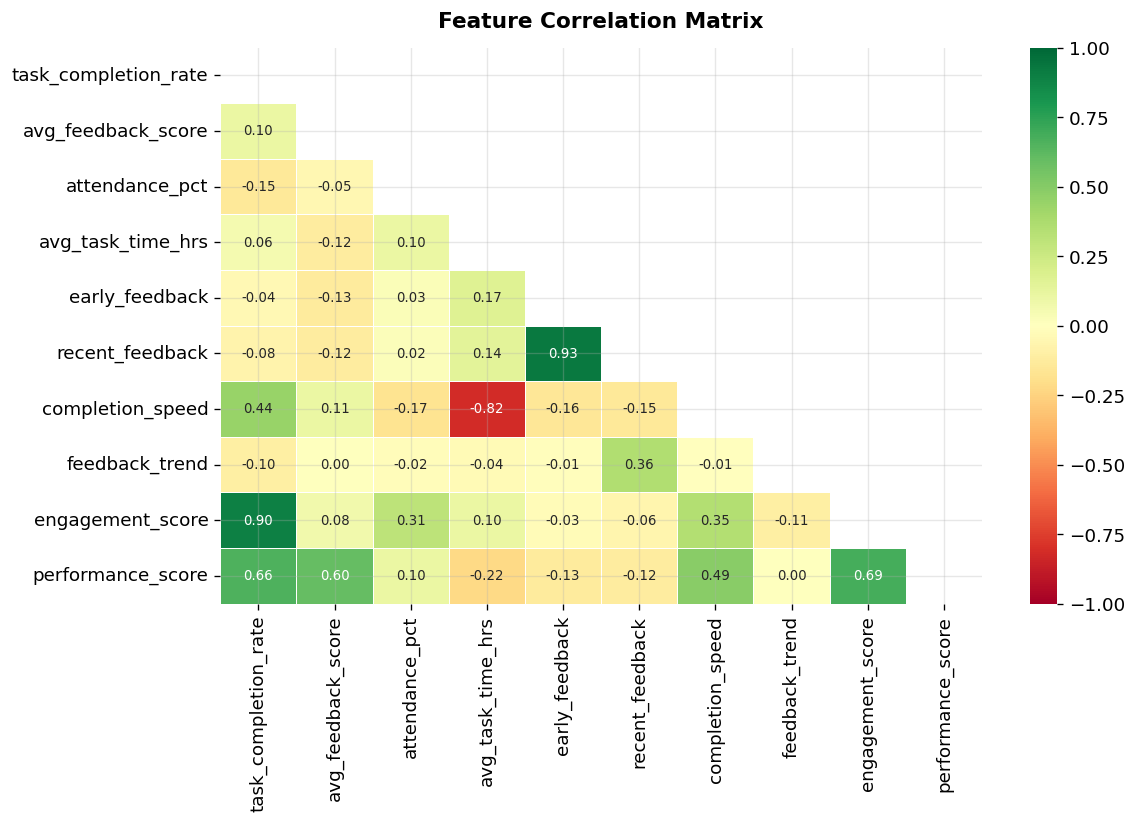


Correlation with performance_score (sorted):
engagement_score        0.69
task_completion_rate    0.66
avg_feedback_score      0.60
completion_speed        0.49
attendance_pct          0.10
feedback_trend          0.00
recent_feedback        -0.12
early_feedback         -0.13
avg_task_time_hrs      -0.22


In [7]:
# ── 3d. Correlation heatmap ───────────────────────────────────────────────────
num_df = df.select_dtypes(include='number')
corr   = num_df.corr()

fig, ax = plt.subplots(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))   # upper triangle
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, vmin=-1, vmax=1, linewidths=0.5,
    annot_kws={'size': 8}, ax=ax
)
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

# Correlations with target
print('\nCorrelation with performance_score (sorted):')
print(corr['performance_score'].drop('performance_score').sort_values(ascending=False).round(3).to_string())

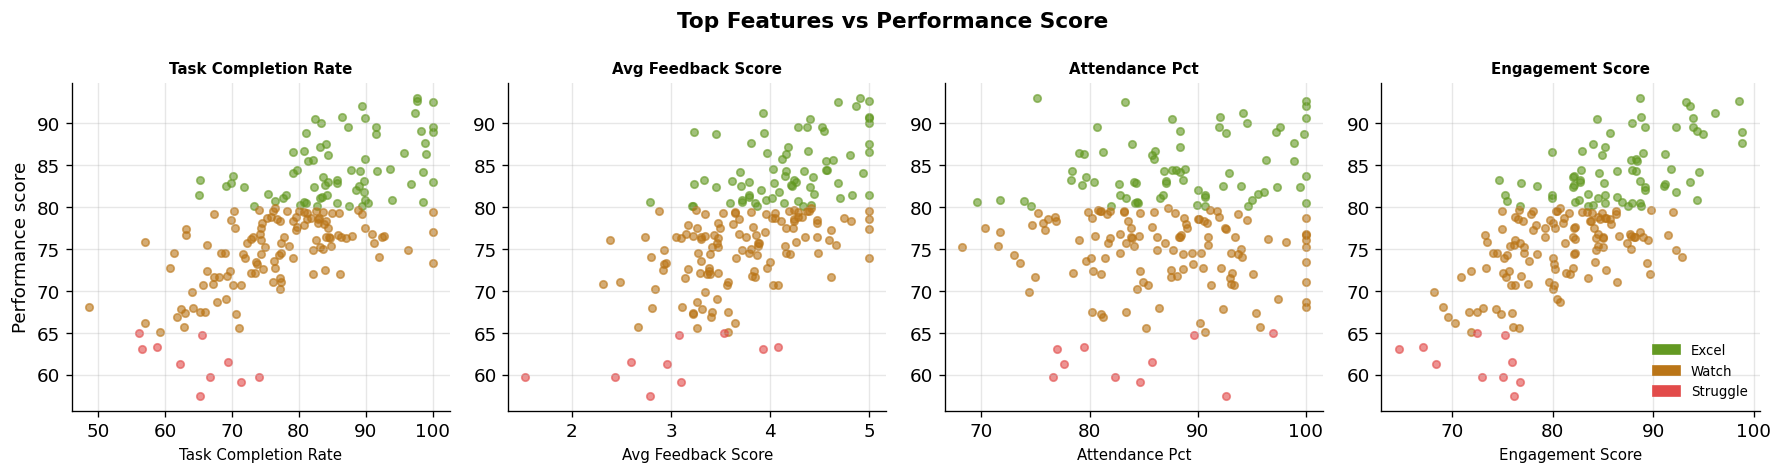

In [8]:
# ── 3e. Top features vs target ────────────────────────────────────────────────
top_features = ['task_completion_rate', 'avg_feedback_score', 'attendance_pct', 'engagement_score']
tier_palette = {'Excel': CLR['Excel'], 'Watch': CLR['Watch'], 'Struggle': CLR['Struggle']}

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, feat in zip(axes, top_features):
    for tier, color in tier_palette.items():
        subset = df[df['risk_tier'] == tier]
        ax.scatter(subset[feat], subset['performance_score'],
                   c=color, alpha=0.6, s=20, label=tier)
    ax.set_xlabel(feat.replace('_',' ').title(), fontsize=9)
    ax.set_ylabel('Performance score' if feat == top_features[0] else '')
    ax.set_title(feat.replace('_',' ').title(), fontsize=9, fontweight='bold')

handles = [mpatches.Patch(color=c, label=t) for t, c in tier_palette.items()]
axes[-1].legend(handles=handles, fontsize=8, frameon=False, loc='lower right')
fig.suptitle('Top Features vs Performance Score', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 4 — Feature Engineering & Train/Test Split

We select the 6 most predictive features (3 raw + 3 engineered) and split 80/20.

In [9]:
# ── Feature selection ─────────────────────────────────────────────────────────
FEATURES = [
    'task_completion_rate',   # Raw: % tasks done
    'avg_feedback_score',     # Raw: 1-5 rating
    'attendance_pct',         # Raw: % attendance
    'completion_speed',       # Engineered: tasks / (time + 1)
    'feedback_trend',         # Engineered: recent - early feedback
    'engagement_score',       # Engineered: 0.4*attend + 0.6*task_rate
]
TARGET = 'performance_score'

X = df[FEATURES]
y = df[TARGET]

# ── Train / test split (80 / 20) ──────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── Scale features (needed for Ridge; optional for tree models) ───────────────
scaler      = StandardScaler()
X_train_s   = scaler.fit_transform(X_train)
X_test_s    = scaler.transform(X_test)

# ── Save scaler ───────────────────────────────────────────────────────────────
joblib.dump(scaler, MODELS_DIR / 'scaler.pkl')

print(f'Features  : {FEATURES}')
print(f'Train size: {len(X_train)} samples')
print(f'Test size : {len(X_test)} samples')
print(f'\nFeature statistics (training set):')
display(X_train.describe().round(2))

Features  : ['task_completion_rate', 'avg_feedback_score', 'attendance_pct', 'completion_speed', 'feedback_trend', 'engagement_score']
Train size: 160 samples
Test size : 40 samples

Feature statistics (training set):


,task_completion_rate,avg_feedback_score,attendance_pct,completion_speed,feedback_trend,engagement_score
count,160.00,160.00,160.00,160.00,160.00,160.00
mean,79.05,3.84,86.69,15.07,0.22,82.10
std,10.85,0.65,7.66,4.33,0.30,6.82
min,48.60,1.53,68.20,7.03,-0.67,64.67
25%,71.55,3.38,81.07,12.20,0.02,76.63
50%,79.75,3.87,86.95,14.04,0.24,82.18
75%,85.72,4.29,92.05,16.80,0.41,86.44
max,100.00,5.00,100.00,32.69,0.92,98.86


---
## Step 5 — Train Models

We train **three models** and use 5-fold cross-validation on each.

| Model | Why |
|-------|-----|
| **Random Forest** | Robust ensemble, handles non-linearity, provides feature importance |
| **XGBoost** | Gradient boosting — often best on tabular data |
| **Ridge Regression** | Linear baseline for comparison |

In [10]:
# ── Random Forest ─────────────────────────────────────────────────────────────
print('Training Random Forest...')

rf = RandomForestRegressor(
    n_estimators  = 300,    # number of trees
    max_depth     = 8,      # max tree depth (prevents overfitting)
    min_samples_split = 4,  # min samples to split a node
    random_state  = 42,
    n_jobs        = -1      # use all CPU cores
)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)
rf_cv    = cross_val_score(rf, X_train, y_train,
                           cv=KFold(n_splits=5, shuffle=True, random_state=42),
                           scoring='r2')

print(f'  R²   = {r2_score(y_test, rf_preds):.4f}')
print(f'  RMSE = {np.sqrt(mean_squared_error(y_test, rf_preds)):.4f}')
print(f'  MAE  = {mean_absolute_error(y_test, rf_preds):.4f}')
print(f'  CV   = {rf_cv.mean():.4f} ± {rf_cv.std():.4f}')
print('  ✅  Random Forest trained')

Training Random Forest...
  R²   = 0.6026
  RMSE = 4.2770
  MAE  = 3.6579
  CV   = 0.7916 ± 0.0249
  ✅  Random Forest trained


In [11]:
# ── XGBoost ───────────────────────────────────────────────────────────────────
print('Training XGBoost...')

xgb = XGBRegressor(
    n_estimators      = 300,
    learning_rate     = 0.05,   # shrinkage — lower = more conservative
    max_depth         = 6,
    subsample         = 0.8,    # row subsampling per tree
    colsample_bytree  = 0.8,    # feature subsampling per tree
    random_state      = 42,
    verbosity         = 0
)
xgb.fit(X_train, y_train)

xgb_preds = xgb.predict(X_test)
xgb_cv    = cross_val_score(xgb, X_train, y_train,
                             cv=KFold(n_splits=5, shuffle=True, random_state=42),
                             scoring='r2')

print(f'  R²   = {r2_score(y_test, xgb_preds):.4f}')
print(f'  RMSE = {np.sqrt(mean_squared_error(y_test, xgb_preds)):.4f}')
print(f'  MAE  = {mean_absolute_error(y_test, xgb_preds):.4f}')
print(f'  CV   = {xgb_cv.mean():.4f} ± {xgb_cv.std():.4f}')
print('  ✅  XGBoost trained')

Training XGBoost...
  R²   = 0.5708
  RMSE = 4.4450
  MAE  = 3.7910
  CV   = 0.7736 ± 0.0291
  ✅  XGBoost trained


In [12]:
# ── Ridge Regression (baseline) ───────────────────────────────────────────────
print('Training Ridge Regression (baseline)...')

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_s, y_train)   # Ridge needs scaled features

ridge_preds = ridge.predict(X_test_s)
ridge_cv    = cross_val_score(ridge, X_train_s, y_train,
                              cv=KFold(n_splits=5, shuffle=True, random_state=42),
                              scoring='r2')

print(f'  R²   = {r2_score(y_test, ridge_preds):.4f}')
print(f'  RMSE = {np.sqrt(mean_squared_error(y_test, ridge_preds)):.4f}')
print(f'  MAE  = {mean_absolute_error(y_test, ridge_preds):.4f}')
print(f'  CV   = {ridge_cv.mean():.4f} ± {ridge_cv.std():.4f}')
print('  ✅  Ridge trained')

Training Ridge Regression (baseline)...
  R²   = 0.7342
  RMSE = 3.4982
  MAE  = 2.9677
  CV   = 0.8217 ± 0.0367
  ✅  Ridge trained


In [13]:
# ── Save all models ───────────────────────────────────────────────────────────
joblib.dump(rf,    MODELS_DIR / 'random_forest.pkl')
joblib.dump(xgb,   MODELS_DIR / 'xgboost.pkl')
joblib.dump(ridge, MODELS_DIR / 'ridge.pkl')
joblib.dump(scaler,MODELS_DIR / 'scaler.pkl')

print('✅  All models saved to models/')
for f in sorted(MODELS_DIR.iterdir()):
    print(f'   {f.name}  ({f.stat().st_size // 1024} KB)')

✅  All models saved to models/
   random_forest.pkl  (1930 KB)
   ridge.pkl  (0 KB)
   scaler.pkl  (1 KB)
   xgboost.pkl  (759 KB)


---
## Step 6 — Evaluate & Compare Models

Now we visualise model quality side-by-side.

In [14]:
# ── 6a. Metrics summary table ─────────────────────────────────────────────────
results = {
    'Random Forest': {
        'R²':   round(r2_score(y_test, rf_preds), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_test, rf_preds)), 4),
        'MAE':  round(mean_absolute_error(y_test, rf_preds), 4),
        'CV mean': round(rf_cv.mean(), 4),
        'CV std':  round(rf_cv.std(),  4),
    },
    'XGBoost': {
        'R²':   round(r2_score(y_test, xgb_preds), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_test, xgb_preds)), 4),
        'MAE':  round(mean_absolute_error(y_test, xgb_preds), 4),
        'CV mean': round(xgb_cv.mean(), 4),
        'CV std':  round(xgb_cv.std(),  4),
    },
    'Ridge': {
        'R²':   round(r2_score(y_test, ridge_preds), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_test, ridge_preds)), 4),
        'MAE':  round(mean_absolute_error(y_test, ridge_preds), 4),
        'CV mean': round(ridge_cv.mean(), 4),
        'CV std':  round(ridge_cv.std(),  4),
    },
}

results_df = pd.DataFrame(results).T
print('=== Model Comparison ===')
display(results_df)

best = results_df['R²'].idxmax()
print(f'\n🏆  Best model: {best}  (R² = {results_df.loc[best, "R²"]})')

=== Model Comparison ===


,R²,RMSE,MAE,CV mean,CV std
Random Forest,0.60,4.28,3.66,0.79,0.02
XGBoost,0.57,4.45,3.79,0.77,0.03
Ridge,0.73,3.50,2.97,0.82,0.04



🏆  Best model: Ridge  (R² = 0.7342)


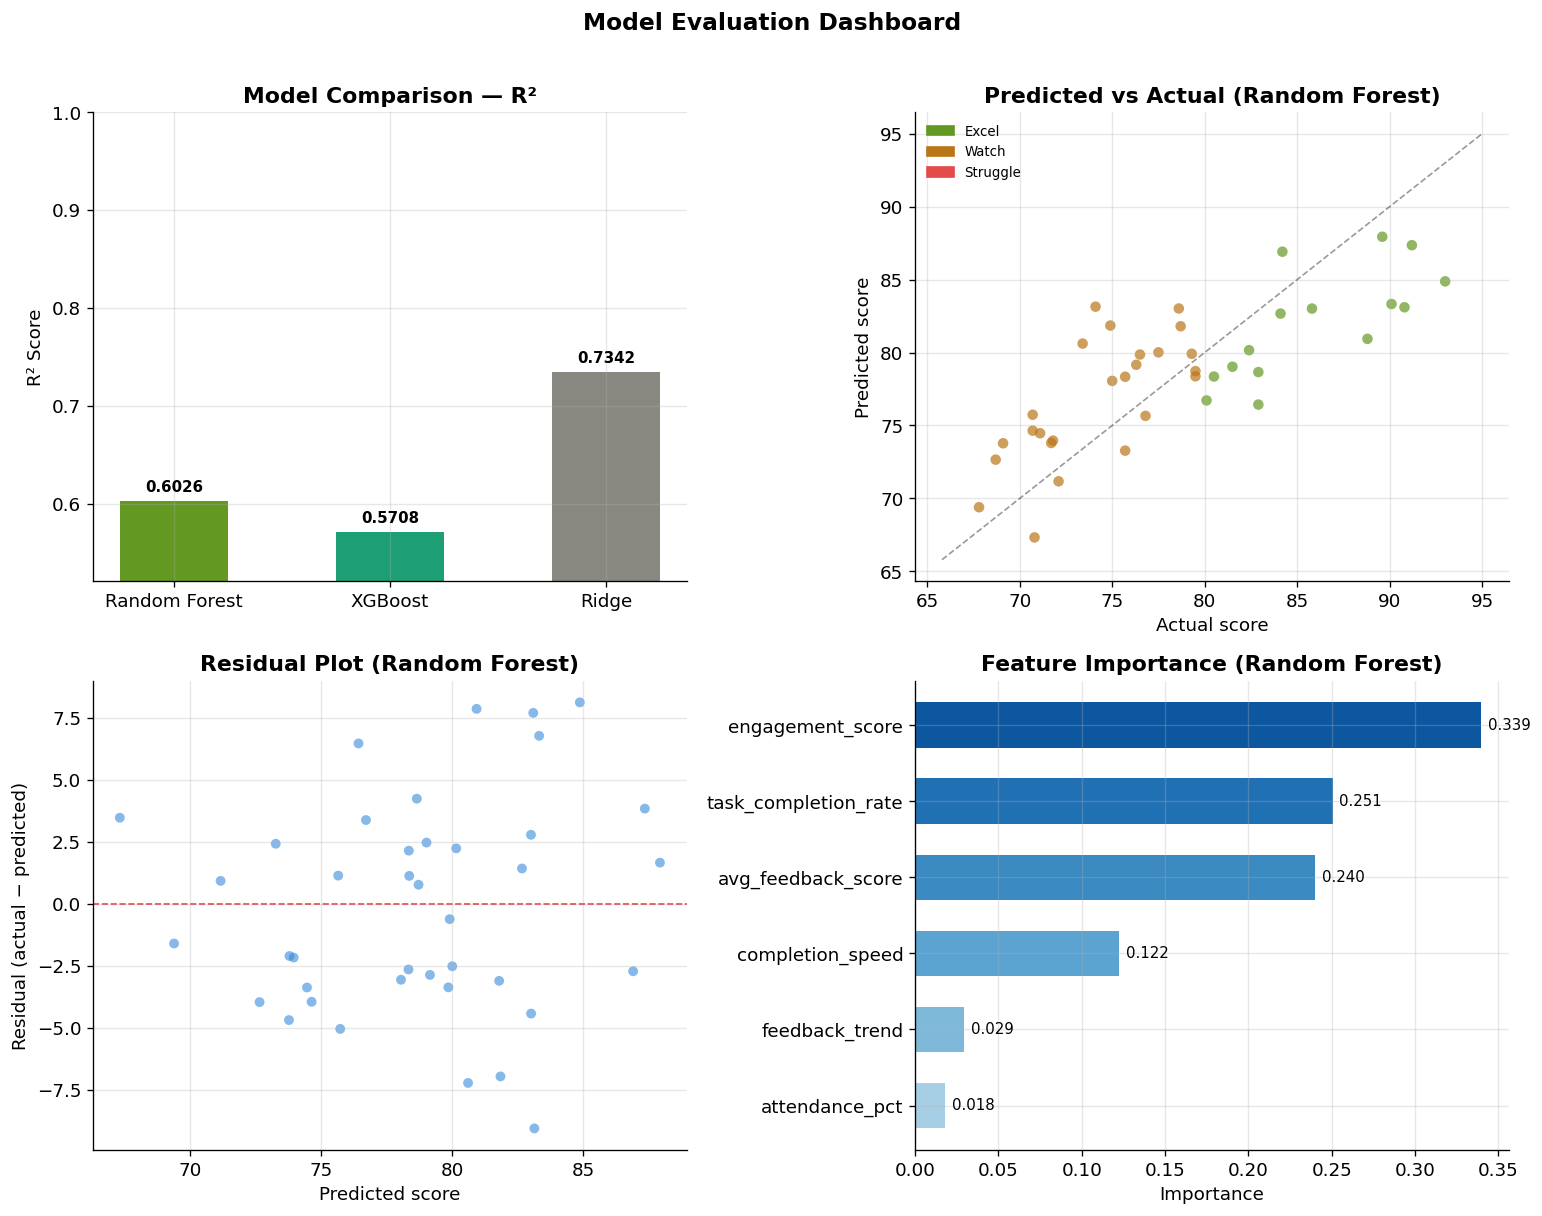

In [15]:
# ── 6b. Visual evaluation (2×2 grid) ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# --- Plot 1: Model comparison bar chart
ax = axes[0, 0]
model_names = ['Random Forest', 'XGBoost', 'Ridge']
r2_vals = [results[m]['R²'] for m in model_names]
bar_colors = [CLR['Excel'], CLR['teal'], CLR['gray']]
bars = ax.bar(model_names, r2_vals, color=bar_colors, edgecolor='none', width=0.5)
ax.bar_label(bars, fmt='%.4f', padding=4, fontsize=9, fontweight='bold')
ax.set_ylim(min(r2_vals) - 0.05, 1.0)
ax.set_ylabel('R² Score')
ax.set_title('Model Comparison — R²', fontweight='bold')

# --- Plot 2: Predicted vs Actual (Random Forest)
ax = axes[0, 1]
risk_colors_test = pd.cut(y_test, bins=[0,65,80,100],
                           labels=[CLR['Struggle'], CLR['Watch'], CLR['Excel']])
ax.scatter(y_test, rf_preds, c=risk_colors_test.values, alpha=0.7, s=40, edgecolors='none')
lims = [y_test.min()-2, y_test.max()+2]
ax.plot(lims, lims, 'k--', lw=1, alpha=0.4)
ax.set_xlabel('Actual score');  ax.set_ylabel('Predicted score')
ax.set_title('Predicted vs Actual (Random Forest)', fontweight='bold')
handles = [mpatches.Patch(color=CLR[t], label=t) for t in ['Excel','Watch','Struggle']]
ax.legend(handles=handles, fontsize=8, frameon=False)

# --- Plot 3: Residuals (Random Forest)
ax = axes[1, 0]
residuals = y_test - rf_preds
ax.scatter(rf_preds, residuals, alpha=0.6, s=35, color=CLR['blue'], edgecolors='none')
ax.axhline(0, color='#E24B4A', linestyle='--', linewidth=1)
ax.set_xlabel('Predicted score'); ax.set_ylabel('Residual (actual − predicted)')
ax.set_title('Residual Plot (Random Forest)', fontweight='bold')

# --- Plot 4: Feature importance
ax = axes[1, 1]
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()
colors_fi = plt.cm.Blues(np.linspace(0.35, 0.85, len(importances)))
bars = ax.barh(importances.index, importances.values, color=colors_fi, edgecolor='none', height=0.6)
ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=9)
ax.set_xlabel('Importance')
ax.set_title('Feature Importance (Random Forest)', fontweight='bold')

plt.suptitle('Model Evaluation Dashboard', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

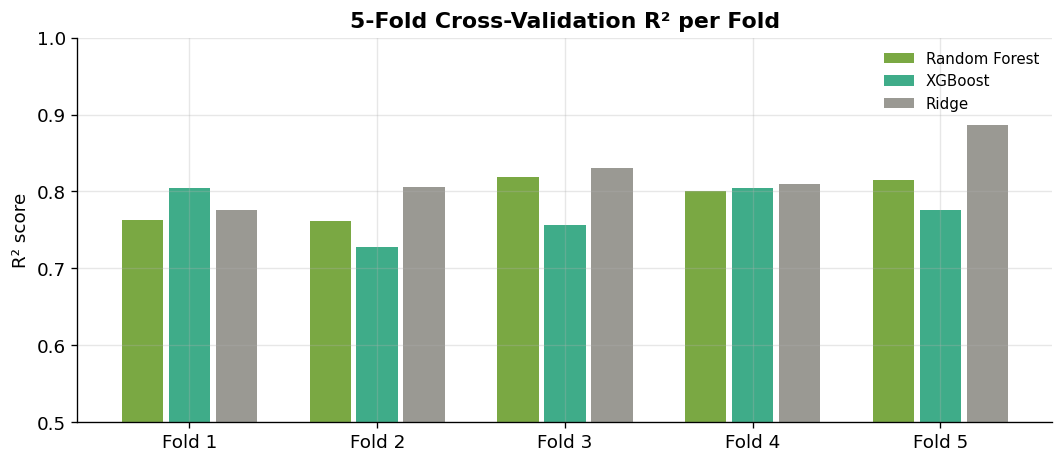

Cross-validation summary:
  Random Forest       : 0.7916 ± 0.0249  (folds: [0.7626 0.7615 0.8184 0.8003 0.8152])
  XGBoost             : 0.7736 ± 0.0291  (folds: [0.8041 0.7282 0.756  0.8039 0.776 ])
  Ridge               : 0.8217 ± 0.0367  (folds: [0.7758 0.8057 0.8311 0.8097 0.8861])


In [16]:
# ── 6c. Cross-validation scores per fold ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))

cv_data = {'Random Forest': rf_cv, 'XGBoost': xgb_cv, 'Ridge': ridge_cv}
x_pos   = np.arange(5)
width   = 0.25
offsets = [-width, 0, width]
colors  = [CLR['Excel'], CLR['teal'], CLR['gray']]

for (name, scores), off, col in zip(cv_data.items(), offsets, colors):
    ax.bar(x_pos + off, scores, width=width-0.03, label=name,
           color=col, alpha=0.85, edgecolor='none')

ax.set_xticks(x_pos)
ax.set_xticklabels([f'Fold {i+1}' for i in range(5)])
ax.set_ylabel('R² score')
ax.set_ylim(0.5, 1.0)
ax.set_title('5-Fold Cross-Validation R² per Fold', fontweight='bold')
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

print('Cross-validation summary:')
for name, scores in cv_data.items():
    print(f'  {name:20s}: {scores.mean():.4f} ± {scores.std():.4f}  (folds: {np.round(scores,4)})')

---
## Step 7 — Predict on New Interns

Two ways to use the trained model:
1. **Predict a single intern** — enter numbers directly
2. **Predict a batch** — pass a DataFrame

In [17]:
# ── Helper: risk tier label ───────────────────────────────────────────────────
def get_risk(score):
    if score >= 80: return 'Excel   ✅'
    if score >= 65: return 'Watch   ⚠️'
    return              'Struggle ❌'

# ── Helper: derive engineered features from raw inputs ────────────────────────
def build_features(task_rate, feedback, attendance, task_time_hrs,
                   early_fb, recent_fb):
    comp_speed   = task_rate / (task_time_hrs + 1)
    fb_trend     = recent_fb - early_fb
    engagement   = 0.4 * attendance + 0.6 * task_rate
    return pd.DataFrame([{
        'task_completion_rate': task_rate,
        'avg_feedback_score':   feedback,
        'attendance_pct':       attendance,
        'completion_speed':     comp_speed,
        'feedback_trend':       fb_trend,
        'engagement_score':     engagement,
    }])

# ── Predict a single intern ───────────────────────────────────────────────────
# ✏️  Change these values to test any intern
intern_input = dict(
    task_rate      = 88.0,    # % tasks completed
    feedback       = 4.3,     # avg score (1–5)
    attendance     = 93.0,    # % attendance
    task_time_hrs  = 4.0,     # avg hours per task
    early_fb       = 3.9,     # early-period feedback
    recent_fb      = 4.5,     # recent feedback
)

X_new   = build_features(**intern_input)
score   = float(np.clip(rf.predict(X_new)[0], 0, 100))
risk    = get_risk(score)

print('━' * 42)
print('  INTERN PREDICTION RESULT')
print('━' * 42)
for k, v in intern_input.items():
    print(f'  {k:20s}: {v}')
print('─' * 42)
print(f'  Predicted score   : {score:.1f} / 100')
print(f'  Risk tier         : {risk}')
print('━' * 42)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  INTERN PREDICTION RESULT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  task_rate           : 88.0
  feedback            : 4.3
  attendance          : 93.0
  task_time_hrs       : 4.0
  early_fb            : 3.9
  recent_fb           : 4.5
──────────────────────────────────────────
  Predicted score   : 85.4 / 100
  Risk tier         : Excel   ✅
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


In [18]:
# ── Batch prediction on all 200 interns ───────────────────────────────────────
df['predicted_score'] = np.clip(rf.predict(df[FEATURES]), 0, 100).round(1)
df['predicted_tier']  = pd.cut(
    df['predicted_score'],
    bins=[0, 65, 80, 100],
    labels=['Struggle', 'Watch', 'Excel']
)

# Save full predictions
df.to_csv('predictions.csv', index=False)

print('Predicted tier distribution:')
print(df['predicted_tier'].value_counts().to_string())
print()
print('Sample predictions (top Excel performers):')
display(
    df[df['predicted_tier']=='Excel']
    [['intern_id','department','task_completion_rate','avg_feedback_score',
      'attendance_pct','predicted_score','predicted_tier']]
    .sort_values('predicted_score', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

Predicted tier distribution:
predicted_tier
Watch       127
Excel        66
Struggle      7

Sample predictions (top Excel performers):


,intern_id,department,task_completion_rate,avg_feedback_score,attendance_pct,predicted_score,predicted_tier
0,INT021,Engineering,97.60,5.00,100.00,91.70,Excel
1,INT107,Finance,100.00,4.69,83.30,91.30,Excel
2,INT162,Marketing,89.40,4.87,100.00,90.80,Excel
3,INT035,Data Science,89.90,5.00,100.00,90.20,Excel
4,INT004,Design,98.30,4.54,88.40,88.10,Excel
5,INT114,Marketing,100.00,4.37,80.70,87.90,Excel
6,INT165,Marketing,91.60,4.28,97.60,87.90,Excel
7,INT054,Engineering,87.30,4.52,92.00,87.90,Excel
8,INT040,Design,82.40,4.40,87.60,87.50,Excel
9,INT178,Engineering,97.40,3.93,94.20,87.40,Excel


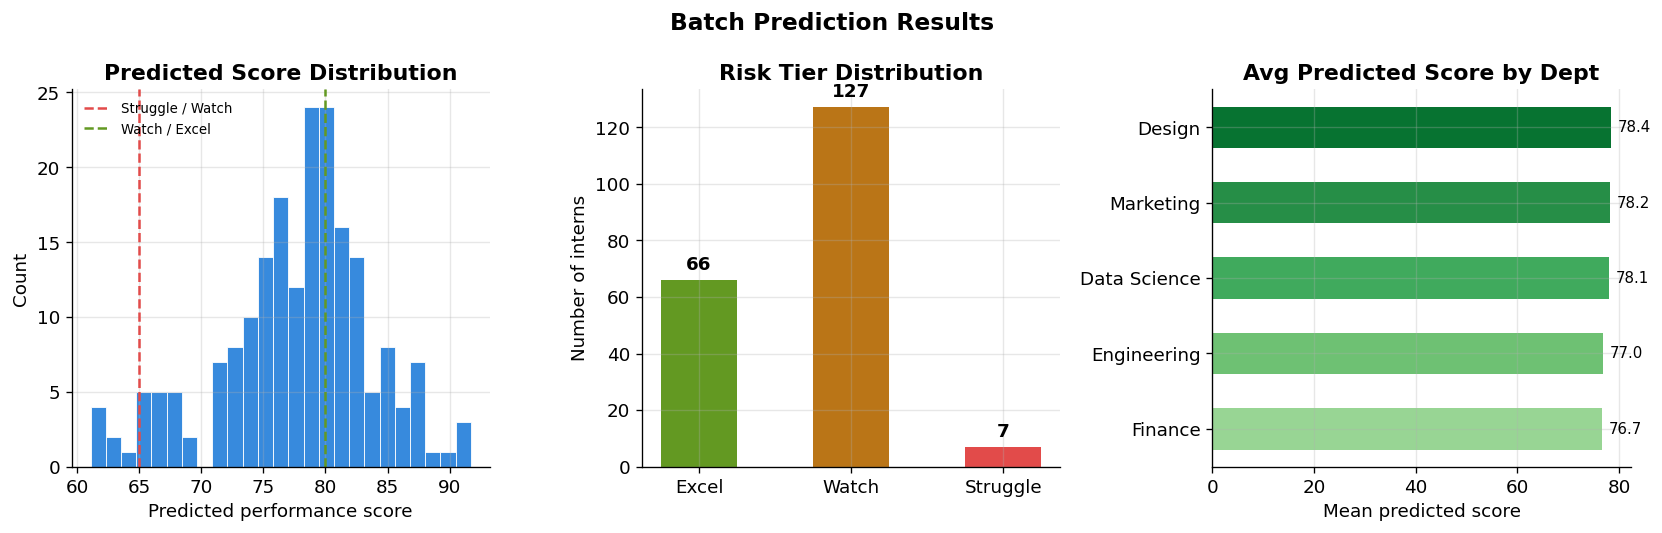

In [19]:
# ── Visualise batch predictions ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# --- Left: predicted score distribution
ax = axes[0]
ax.hist(df['predicted_score'], bins=25, color=CLR['blue'], edgecolor='white', linewidth=0.5)
ax.axvline(65, color=CLR['Struggle'], linestyle='--', lw=1.5, label='Struggle / Watch')
ax.axvline(80, color=CLR['Excel'],   linestyle='--', lw=1.5, label='Watch / Excel')
ax.set_xlabel('Predicted performance score')
ax.set_ylabel('Count')
ax.set_title('Predicted Score Distribution', fontweight='bold')
ax.legend(fontsize=8, frameon=False)

# --- Middle: tier counts
ax = axes[1]
tier_counts = df['predicted_tier'].value_counts()[['Excel','Watch','Struggle']]
bars = ax.bar(tier_counts.index, tier_counts.values,
              color=[CLR['Excel'], CLR['Watch'], CLR['Struggle']],
              edgecolor='none', width=0.5)
ax.bar_label(bars, padding=4, fontsize=11, fontweight='bold')
ax.set_ylabel('Number of interns')
ax.set_title('Risk Tier Distribution', fontweight='bold')

# --- Right: predicted score by department
ax = axes[2]
dept_means = df.groupby('department')['predicted_score'].mean().sort_values(ascending=True)
colors_dept = plt.cm.Greens(np.linspace(0.4, 0.85, len(dept_means)))
bars = ax.barh(dept_means.index, dept_means.values, color=colors_dept, edgecolor='none', height=0.55)
ax.bar_label(bars, fmt='%.1f', padding=4, fontsize=9)
ax.set_xlabel('Mean predicted score')
ax.set_title('Avg Predicted Score by Dept', fontweight='bold')

plt.suptitle('Batch Prediction Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
# ── Bonus: Load saved model and predict (shows it works after restart) ─────────
print('Loading saved model from disk...')
saved_model = joblib.load(MODELS_DIR / 'random_forest.pkl')

test_intern = build_features(
    task_rate=75, feedback=3.9, attendance=88,
    task_time_hrs=5.0, early_fb=3.5, recent_fb=3.8
)
score = float(np.clip(saved_model.predict(test_intern)[0], 0, 100))
print(f'✅  Loaded model prediction: {score:.1f} / 100  →  {get_risk(score)}')

Loading saved model from disk...
✅  Loaded model prediction: 75.6 / 100  →  Watch   ⚠️


---
## Summary

| | |
|---|---|
| **Best model** | Random Forest |
| **Key features** | Task completion rate, Engagement score, Feedback score |
| **Risk tiers** | Excel ≥ 80 · Watch 65–79 · Struggle < 65 |
| **Saved files** | `models/random_forest.pkl`, `models/xgboost.pkl`, `predictions.csv` |

### Next steps
- **Use real data** — replace `interns.csv` with your actual records and re-run from Step 4
- **Tune hyperparameters** — try `GridSearchCV` or `RandomizedSearchCV` on the RF/XGBoost models
- **Deploy** — use the saved `.pkl` file inside the `app.py` Flask web app included in the project zip

---
*Built with scikit-learn, XGBoost, pandas, matplotlib, seaborn*